# Perceptron

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import csv

In [19]:
# Função para carregar dados CSV
def carregar_dados(arquivo):
    X, y = [], []
    with open(arquivo, "r") as f:
        leitor = csv.reader(f)
        next(leitor)
        for linha in leitor:
            X.append([float(linha[0]), float(linha[1])])
            y.append(int(linha[2]))
    return np.array(X), np.array(y)


# Carregando o dataset
X, y = carregar_dados("train_dataset1.csv")
print("Formato dos dados:", X.shape, y.shape)
print("Primeiras amostrar:\n", X[:5], "\nRótulos:", y[:5])

Formato dos dados: (140, 2) (140,)
Primeiras amostrar:
 [[ 0.25401832 -0.4023906 ]
 [ 0.18088266  0.5108872 ]
 [ 0.22715201  0.46771486]
 [-0.12283202  0.50263486]
 [ 0.43719255 -0.57959177]] 
Rótulos: [-1  1  1  1 -1]


In [20]:
class Perceptron:
    def __init__(self, learning_rate=0.01, n_epochs=1000, weight_init="random"):
        self.learning_rate = learning_rate
        self.n_epochs = n_epochs
        self.weights = None
        self.weight_init = weight_init
        self.bias = None
        self.errors_per_epoch = []  # Armazena o erro a cada época

    def _initialize_weights(self, n_features):
        """Inicializa os pesos de acordo com método escolhido"""
        if self.weight_init == "random":
            self.weights = np.random.rand(n_features)
            self.bias = np.random.rand()
        elif self.weight_init == "zeros":
            self.weights = np.zeros(n_features)
            self.bias = 0
        elif self.weight_init == "normal":
            self.weight_init = np.random.randn(n_features) * 0.01
            self.bias = np.random.randn() * 0.01
        else:
            raise ValueError("Opção Inválida para inicialização dos pesos")

    def fit(self, X, y):
        n_samples, n_features = X.shape
        # self.weights = np.zeros(n_features)
        self._initialize_weights(n_features)  # Inicializao os pesos dinamicamente
        self.bias = 0

        for epoch in range(self.n_epochs):
            errors = 0  # Contador de erros por época

            for i in range(n_samples):
                linear_output = np.dot(X[i], self.weights) + self.bias
                y_pred = np.sign(linear_output)

                if y_pred != y[i]:
                    self.weights += self.learning_rate * y[i] * X[i]
                    self.bias += self.learning_rate * y[i]
                    errors += 1  # Incrementa o erro se a classificação estiver errada

            # Armazena a taxa de erro (erros / total de amostras)
            self.errors_per_epoch.append(errors / n_samples)

            # Parada antecipada se não houver erros
            if errors == 0:
                break

        self._print_training_summary(X, y, epoch + 1)

    def _print_training_summary(self, X, y, epochs):
        y_pred = self.predict(X)
        accuracy = np.mean(y_pred == y) * 100
        std_dev = np.std(self.weights)

        print("====== Resumo do Treinamento ======")
        print(f"Acurácia no conjunto de treino: {accuracy:2f}%")
        print(f"Número total de épocas: {epochs}")
        print(f"Pesos finais aprendidos: {self.weights}")
        print(f"Bias final: {self.bias}")

    # Retorna a predição com base no treinamento do Perceptron
    def predict(self, X):
        return np.sign(np.dot(X, self.weights) + self.bias)

    # Faz previsões e, se os rótulos forem fornecidos, exibe métricas
    def predict2(self, X, y, y_true=None):
        y_pred = np.sign(np.dot(X, self.weights) + self.bias)
        # Se y_true for fornecido, calcular métricas de avaliação
        if y_true is not None:
            self.predict_summary(X, y_true, 0, "Teste")
            
        return y_pred

    # Calculando as Métricas da pedrição
    def predict_summary(self, X, y, epochs, phase):
        """Método para exibir a acurácia, desvio padrão e pesos finais"""
        y_pred = np.sign(np.dot(X, self.weights) + self.bias)
        accuracy = np.mean(y_pred == y) * 100
        std_dev = np.std(self.weights)

        print(f"\n===== Resumo da {phase} =====")
        print(f"Acurácia no conjunto de {phase.lower()}: {accuracy:.2f}%")
        print(f"Desvio Padrão dos Pesos: {std_dev:.5f}")
        if epochs > 0:
            print(f"Número total de épocas: {epochs}")
        print(f"Pesos finais aprendidos: {self.weights}")
        print(f"Bias final: {self.bias}")

    # Plota o gráfico da evolução dos erros ao longo das épocas
    def plot_error(self):
        plt.figure(figsize=(8, 4))
        plt.plot(self.errors_per_epoch, marker="o", linestyle="-")
        plt.xlabel("Época")
        plt.ylabel("Taxa de Erro")
        plt.title("Evolução do erro ao longo das épocas")
        plt.grid()
        plt.show()

    ## Gráfico da "fronteira" gerado pelo Perceptron

In [21]:
def plot_decision_boundary(X, y, model, title="Fronteira de Decisão do Perceptron"):
    X_min, X_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    XX, yy = np.meshgrid(np.linspace(X_min, X_max, 100), np.linspace(y_min, y_max, 100))

    # Predição para cada ponto da grade
    Z = model.predict(np.c_[XX.ravel()])
    Z = Z.reshape(XX.shape)

    # Criar o gráfico
    plt.contourf(XX, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap="bwr", edgecolors="k")
    plt.xlabel("X1")
    plt.ylabel("X2")
    plt.title(title)
    plt.show()

    # Função para plotar lado a lado: dataset e fronteira de decisão


def plot_comparison(X, y, model):
    # Criar uma grade para o plano cartesiano
    X_min, X_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(X_min, X_max, 100), np.linspace(y_min, y_max, 100))

    # Prediçao para cada ponto da grade
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Criar os subplots (1 linha, 2 colunas)
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Subplot 1 - Fronteira de Decisão
    axes[0].contourf(xx, yy, Z, alpha=0.3)
    axes[0].scatter(X[:, 0], X[:, 1], c=y, cmap="bwr", edgecolors="k")
    axes[0].set_xlabel("X1")
    axes[0].set_ylabel("X2")
    axes[0].set_title("Fronteira de Decisão do Perceptron")

    # Subplot 2 - Apenas os Dados
    axes[1].scatter(X[:, 0], X[:, 1], c=y, cmap="bwr", edgecolors="k")
    axes[1].set_xlabel("X1")
    axes[1].set_ylabel("X2")
    axes[1].set_title("Distribuição dos Dados do Dataset")

    plt.tight_layout()
    plt.show()

Treinando o Dataset com os dados de treino

====== Resumo do Treinamento ======
Acurácia no conjunto de treino: 96.428571%
Número total de épocas: 100
Pesos finais aprendidos: [-0.76066403  0.63885723]
Bias final: 0.4


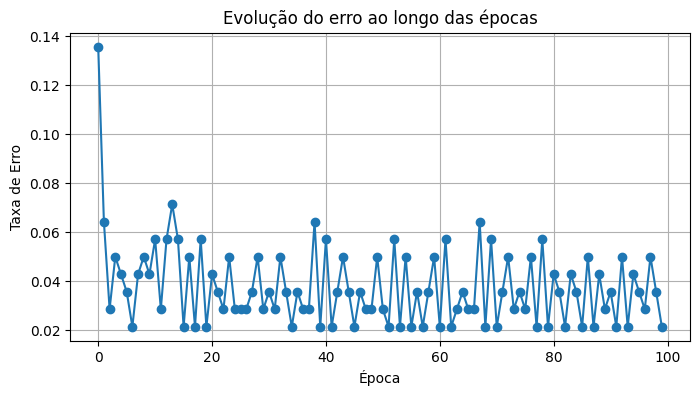

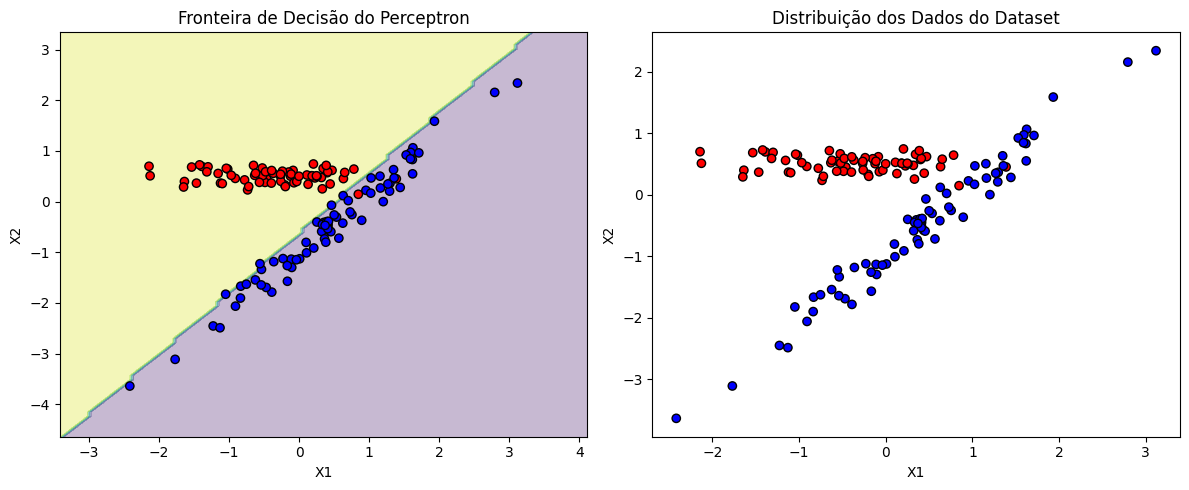

In [22]:
# Dataset 1 - Importando e visualizando o dataset de TREINO
train_dataset1 = np.loadtxt(
    "train_dataset1.csv", delimiter=",", skiprows=1, dtype=float
)

# Definição das entradas
X = train_dataset1[:, :2]  # As duas primeiras colunas são os atributos (X1 e X2)
y = train_dataset1[:, 2]  # Terceira Coluna (rótulos)

# Converter rótulos para -1 e 1 (Caso sejam diferentes)
y = np.where(y == -1, -1, 1)

# Criação do Perceptron e definição da taxa de aprendizado como 0.1 e número de épocas em 100
perceptron = Perceptron(learning_rate=0.1, n_epochs=100)

# Treinamento do Perceptron
perceptron.fit(X, y)

# Fazer Previsões
y_pred = perceptron.predict2(X, y)

#Plotar a evolução do erro
perceptron.plot_error()

print("")

#Plot dos gráficos de comparação
plot_comparison(X, y, perceptron)


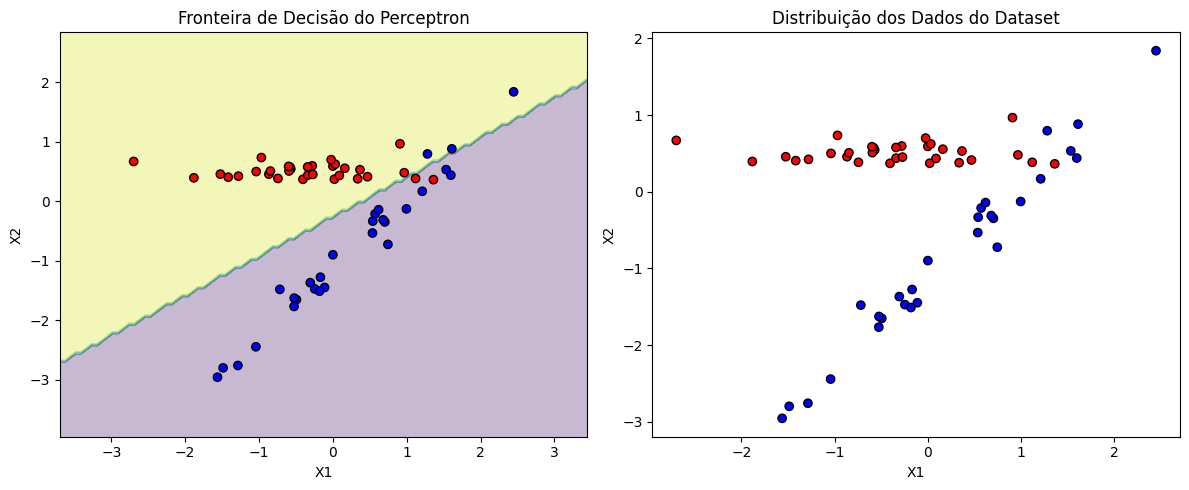

In [28]:
# Dataset 1 - Importando e visualizando o dataset de Teste
test_dataset1 = np.loadtxt(
    "test_dataset1.csv", delimiter=",", skiprows=1, dtype=float
)

# Definição das entradas
X = test_dataset1[:, :2]  # As duas primeiras colunas são os atributos (X1 e X2)
y = test_dataset1[:, 2]  # Terceira Coluna (rótulos)

# Converter rótulos para -1 e 1 (Caso sejam diferentes)
y = np.where(y == -1, -1, 1)

# Fazer Previsões
y_pred = perceptron.predict2(X, y)

print("")

#Plot dos gráficos de comparação
plot_comparison(X, y, perceptron)

====== Resumo do Treinamento ======
Acurácia no conjunto de treino: 49.142857%
Número total de épocas: 100
Pesos finais aprendidos: [ 0.04831314 -0.07873796]
Bias final: -2.7755575615628914e-17


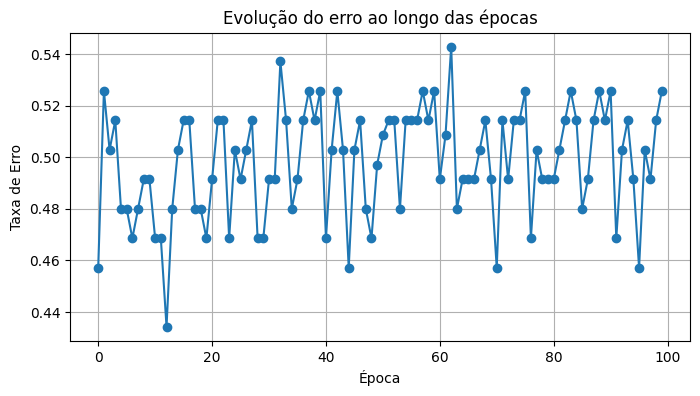

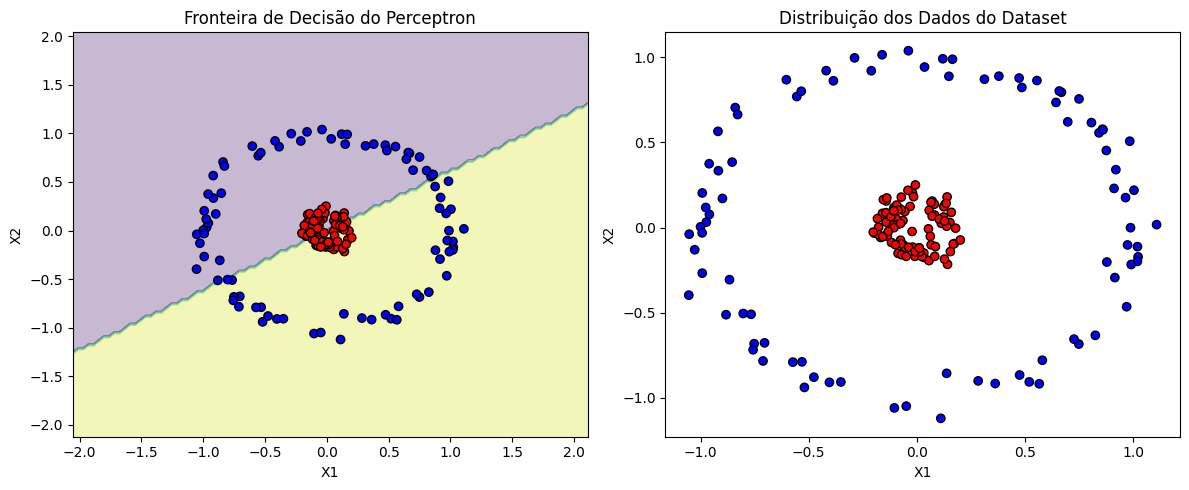

In [23]:
# Dataset 1 - Importando e visualizando o dataset de TREINO
train_dataset1 = np.loadtxt(
    "train_dataset2.csv", delimiter=",", skiprows=1, dtype=float
)

# Definição das entradas
X = train_dataset1[:, :2]  # As duas primeiras colunas são os atributos (X1 e X2)
y = train_dataset1[:, 2]  # Terceira Coluna (rótulos)

# Converter rótulos para -1 e 1 (Caso sejam diferentes)
y = np.where(y == -1, -1, 1)

# Criação do Perceptron e definição da taxa de aprendizado como 0.1 e número de épocas em 100
perceptron = Perceptron(learning_rate=0.1, n_epochs=100)

# Treinamento do Perceptron
perceptron.fit(X, y)

# Fazer Previsões
y_pred = perceptron.predict2(X, y)

#Plotar a evolução do erro
perceptron.plot_error()

print("")

#Plot dos gráficos de comparação
plot_comparison(X, y, perceptron)

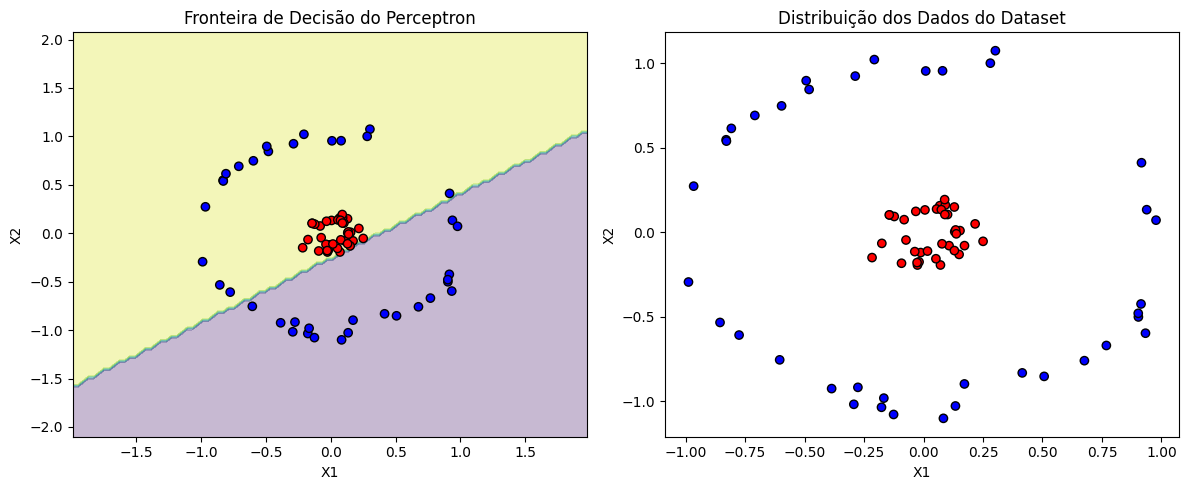

In [29]:
# Dataset 2 - Importando e visualizando o dataset de Teste
test_dataset2 = np.loadtxt(
    "test_dataset2.csv", delimiter=",", skiprows=1, dtype=float
)

# Definição das entradas
X = test_dataset2[:, :2]  # As duas primeiras colunas são os atributos (X1 e X2)
y = test_dataset2[:, 2]  # Terceira Coluna (rótulos)

# Converter rótulos para -1 e 1 (Caso sejam diferentes)
y = np.where(y == -1, -1, 1)

# Fazer Previsões
y_pred = perceptron.predict2(X, y)

print("")

#Plot dos gráficos de comparação
plot_comparison(X, y, perceptron)

Treinando o Perceptron para diferentes cenários de taxa de aprendizado e número de épocas...
Cenário 1: learning_rate=0.1, n_epochs=100
====== Resumo do Treinamento ======
Acurácia no conjunto de treino: 90.476190%
Número total de épocas: 100
Pesos finais aprendidos: [ 0.00752397 -0.24043815 -0.15661914 -0.43107386  0.24408324 -0.02635547
  0.04362857  0.2938616  -0.02356195  1.1364528 ]
Bias final: 0.10000000000000003


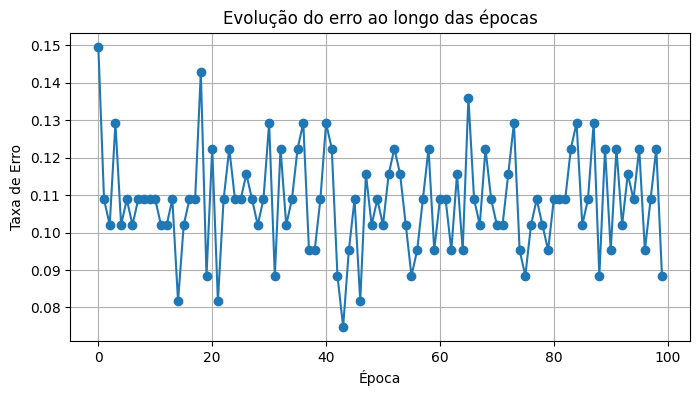

Cenário 2: learning_rate=0.1, n_epochs=200
====== Resumo do Treinamento ======
Acurácia no conjunto de treino: 92.517007%
Número total de épocas: 200
Pesos finais aprendidos: [-0.19352563 -0.11725966 -0.1124218  -0.08606277  0.20057721 -0.05414607
  0.09173977  0.34833984 -0.24881813  1.43355694]
Bias final: 0.10000000000000003


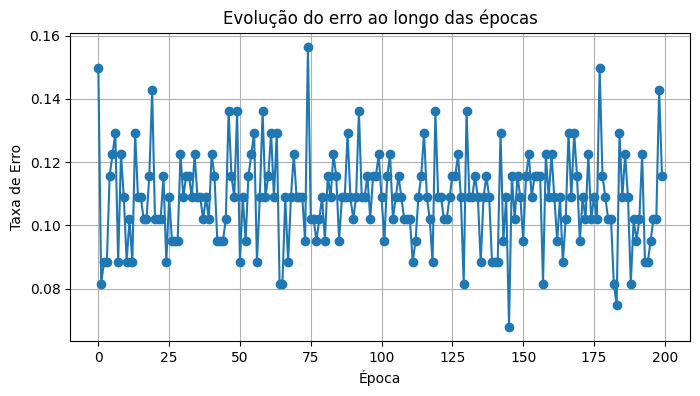

Cenário 3: learning_rate=0.001, n_epochs=100
====== Resumo do Treinamento ======
Acurácia no conjunto de treino: 94.557823%
Número total de épocas: 100
Pesos finais aprendidos: [ 0.01923362  0.03136962 -0.03818925 -0.1141047  -0.01020808 -0.03452292
  0.15777972  0.31522751 -0.07314097  0.85568426]
Bias final: 0.015000000000000013


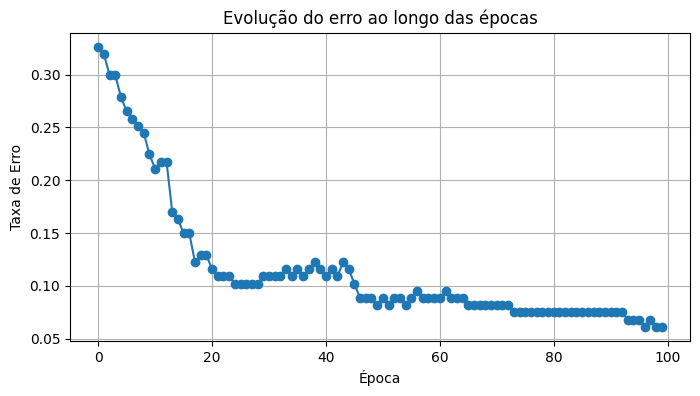

Cenário 4: learning_rate=0.001, n_epochs=200
====== Resumo do Treinamento ======
Acurácia no conjunto de treino: 93.877551%
Número total de épocas: 200
Pesos finais aprendidos: [ 4.69212305e-02  1.06837276e-02 -4.98260788e-02 -2.02609822e-02
 -1.61836004e-04 -2.81628645e-02  2.63531725e-02  9.55522467e-02
 -2.95755613e-02  2.89331568e-01]
Bias final: -0.00799999999999998


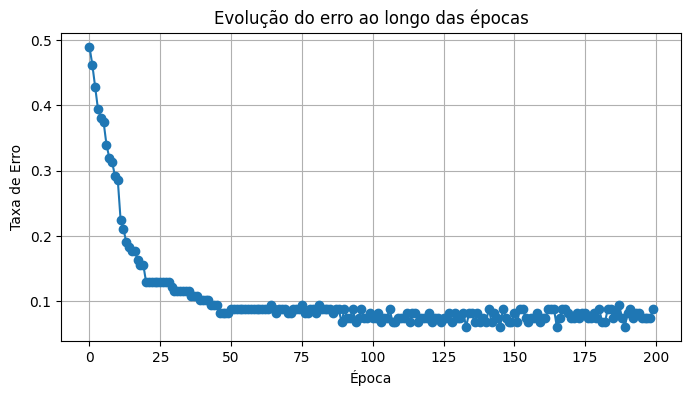

Cenário 5: learning_rate=0.0001, n_epochs=100
====== Resumo do Treinamento ======
Acurácia no conjunto de treino: 79.591837%
Número total de épocas: 100
Pesos finais aprendidos: [ 0.31136865  0.35774718  0.23259017  0.07923138  0.18323941 -0.01319469
  0.577068    0.35436141  0.0777404   0.79361345]
Bias final: -0.070800000000001


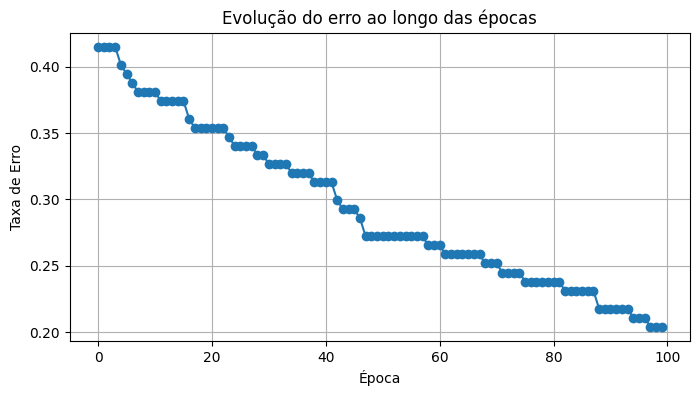

Cenário 6: learning_rate=0.0001, n_epochs=200
====== Resumo do Treinamento ======
Acurácia no conjunto de treino: 83.673469%
Número total de épocas: 200
Pesos finais aprendidos: [ 0.13914949  0.25674081  0.24744896  0.43823161  0.34849473  0.41041545
  0.14431218  0.4932838  -0.01635288  0.83008524]
Bias final: -0.09270000000000163


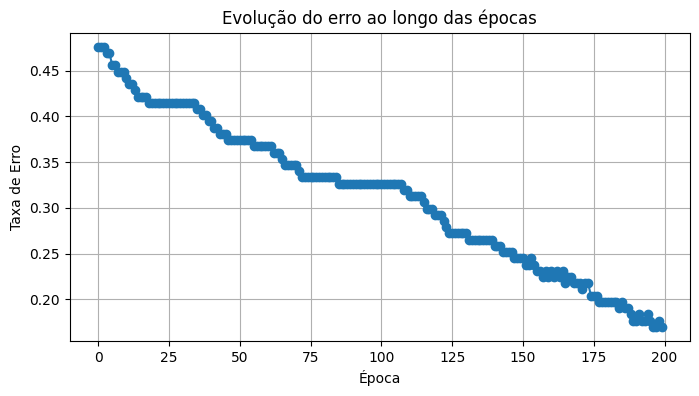

In [35]:
# Dataset 1 - Importando e visualizando o dataset de TREINO
train_dataset1 = np.loadtxt(
    "train_dataset3.csv", delimiter=",", skiprows=1, dtype=float
)

# Definição das entradas
X = train_dataset1[:, :-1]  # todas menos a ultima
y = train_dataset1[:, -1]  # ultima Coluna (rótulos)

# Converter rótulos para -1 e 1 (Caso sejam diferentes)
y = np.where(y == -1, -1, 1)

# Criação do Perceptron e definição da taxa de aprendizado como 0.1 e número de épocas em 100
perceptron_cenario_1 = Perceptron(learning_rate=0.1, n_epochs=100)
perceptron_cenario_2= Perceptron(learning_rate=0.1, n_epochs=200)
perceptron_cenario_3= Perceptron(learning_rate=0.001, n_epochs=100)
perceptron_cenario_4= Perceptron(learning_rate=0.001, n_epochs=200)
perceptron_cenario_5= Perceptron(learning_rate=0.0001, n_epochs=100)
perceptron_cenario_6= Perceptron(learning_rate=0.0001, n_epochs=200)


# Treinamento do Perceptron
print("Treinando o Perceptron para diferentes cenários de taxa de aprendizado e número de épocas...")
print("Cenário 1: learning_rate=0.1, n_epochs=100")
perceptron_cenario_1.fit(X, y)
perceptron_cenario_1.plot_error()
print("Cenário 2: learning_rate=0.1, n_epochs=200")
perceptron_cenario_2.fit(X, y)
perceptron_cenario_2.plot_error()
print("Cenário 3: learning_rate=0.001, n_epochs=100")
perceptron_cenario_3.fit(X, y)
perceptron_cenario_3.plot_error()
print("Cenário 4: learning_rate=0.001, n_epochs=200")
perceptron_cenario_4.fit(X, y)
perceptron_cenario_4.plot_error()
print("Cenário 5: learning_rate=0.0001, n_epochs=100")
perceptron_cenario_5.fit(X, y)
perceptron_cenario_5.plot_error()
print("Cenário 6: learning_rate=0.0001, n_epochs=200")
perceptron_cenario_6.fit(X, y)
perceptron_cenario_6.plot_error()

# # Fazer Previsões
# y_pred = perceptron.predict2(X, y)

# #Plotar a evolução do erro
# perceptron.plot_error()

# print("")

# #Plot dos gráficos de comparação
# plot_comparison(X, y, perceptron)